In [1]:
from mofgbmlpy.utility.parallel_cross_validation import run_cross_validation
from datetime import datetime

current_time = datetime.now()
time_str = current_time.strftime("%Y_%m_%d_%H_%M_%S")

datasets = ["iris", "pima", "bupa", "phoneme"]

## NSGA-II

In [ ]:
for data_name in datasets:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "nsga2",
    ]
    
    run_cross_validation(args, dataset_root)

Running cross-validation experiments:   0%|          | 0/30 [00:18<?, ? experiment/s]


=========== DATASET iris ===========



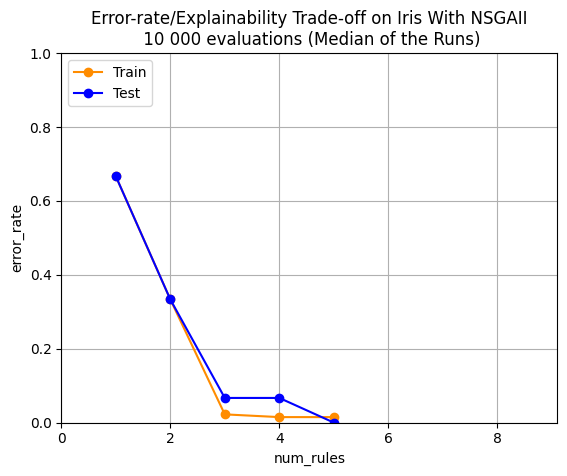

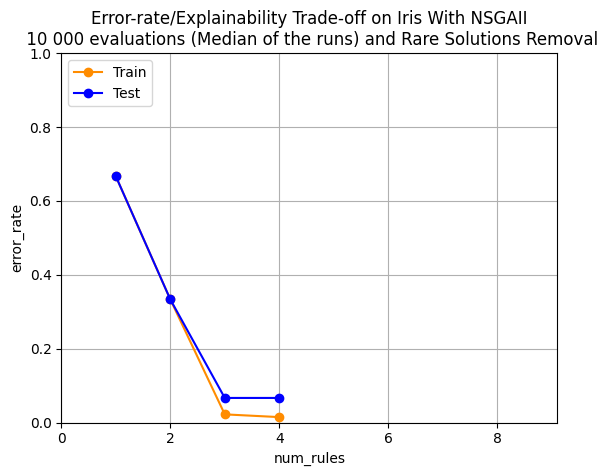

run times:
Q1:  14.14505159854889
Median :  14.576715588569641
Q3:  15.046111285686493
Average :  14.249620644251506
Std:  1.1839762118150507
=========== DATASET pima ===========



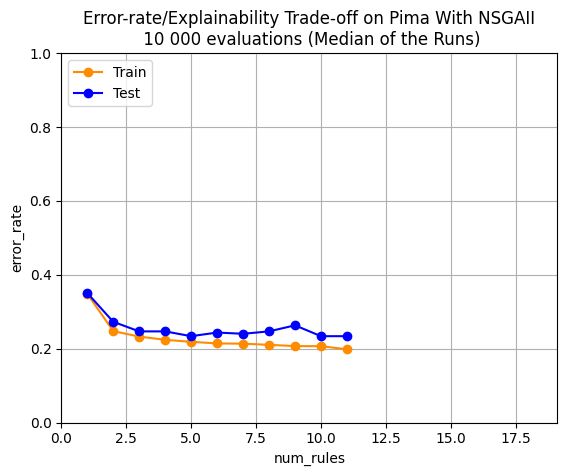

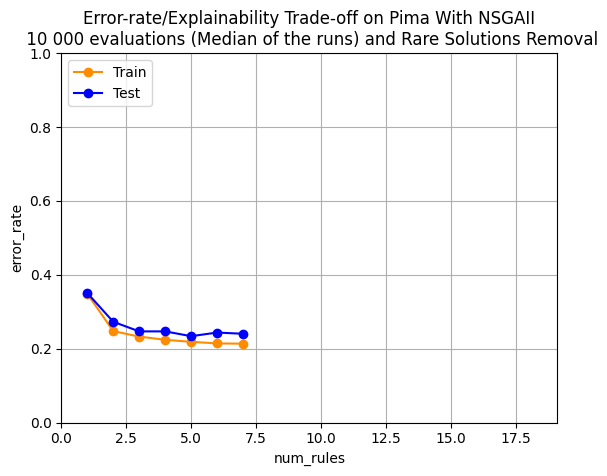

run times:
Q1:  47.86529004573822
Median :  51.37776219844818
Q3:  52.86149334907532
Average :  50.0614825407664
Std:  5.135084857751146
=========== DATASET bupa ===========



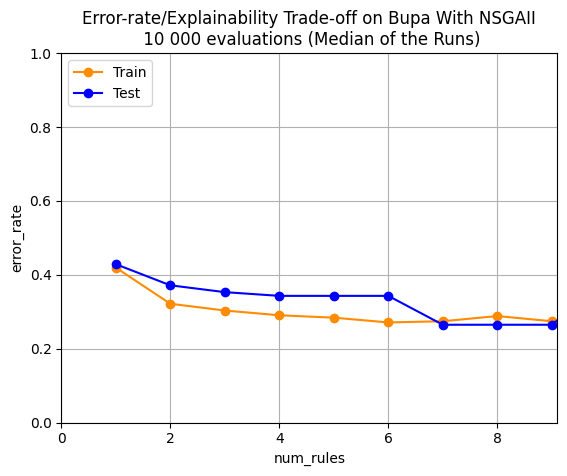

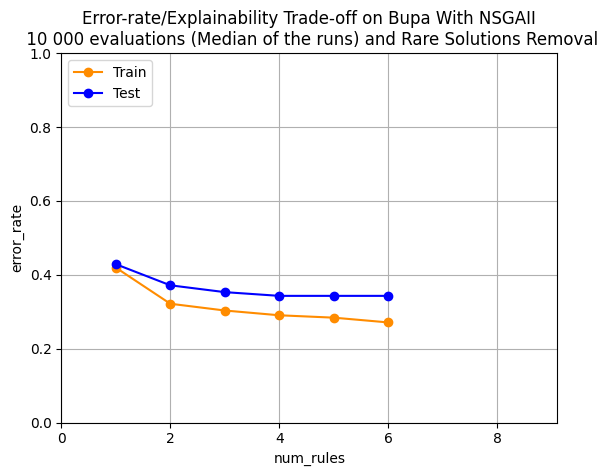

run times:
Q1:  21.606749713420868
Median :  23.594436287879944
Q3:  24.817959249019623
Average :  23.2548495610555
Std:  2.6002048425820723
=========== DATASET phoneme ===========



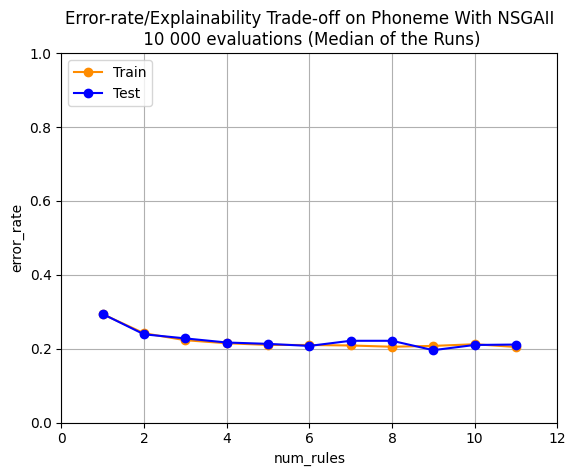

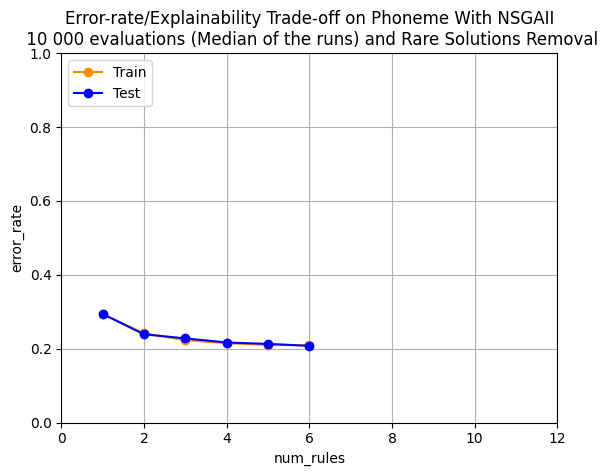

run times:
Q1:  261.98328280448914
Median :  274.78425550460815
Q3:  281.6844115257263
Average :  263.21909749507904
Std:  32.85775657300759


In [3]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,9.1),
    "pima": (0,19.1),
    "bupa": (0,9.1),
    "phoneme": (0, 12)
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in datasets:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]
    
    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/nsgaii_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)
        
    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()
    print("run times:")
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))


## MOEA/D

In [4]:
for data_name in datasets:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", "10000",
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "moead",
    ]

    run_cross_validation(args, dataset_root)

Running cross-validation experiments: 100%|██████████| 30/30 [00:57<00:00,  1.91s/ experiment]


Execution time: 57.75


Running cross-validation experiments: 100%|██████████| 30/30 [02:29<00:00,  4.99s/ experiment]


Execution time: 150.12


Running cross-validation experiments: 100%|██████████| 30/30 [01:21<00:00,  2.72s/ experiment]


Execution time: 81.91


Running cross-validation experiments: 100%|██████████| 30/30 [13:26<00:00, 26.88s/ experiment]  


Execution time: 807.04


=========== DATASET iris ===========



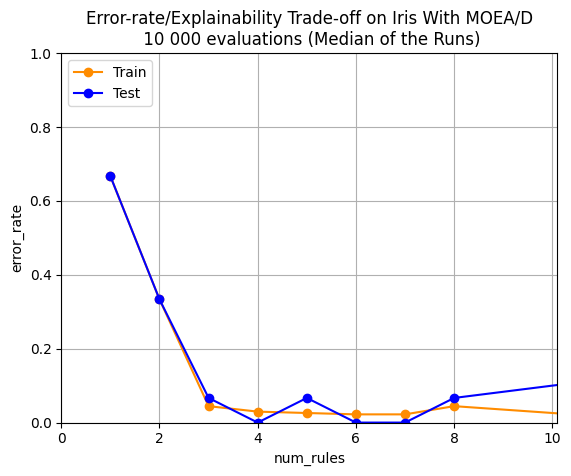

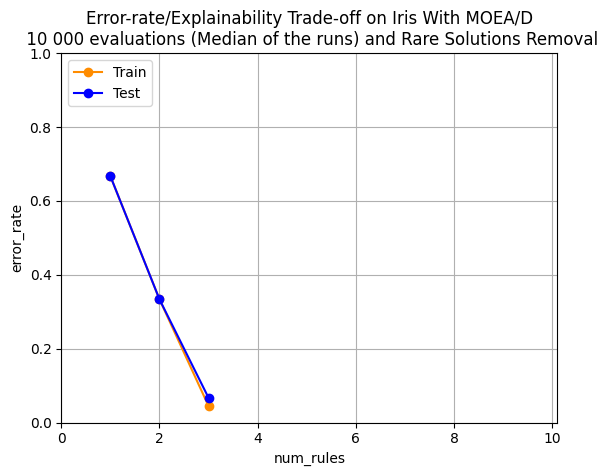

run times:
Q1:  15.979002892971039
Median :  16.263607263565063
Q3:  16.571137130260468
Average :  15.831581735610962
Std:  1.2080930317752518
=========== DATASET pima ===========



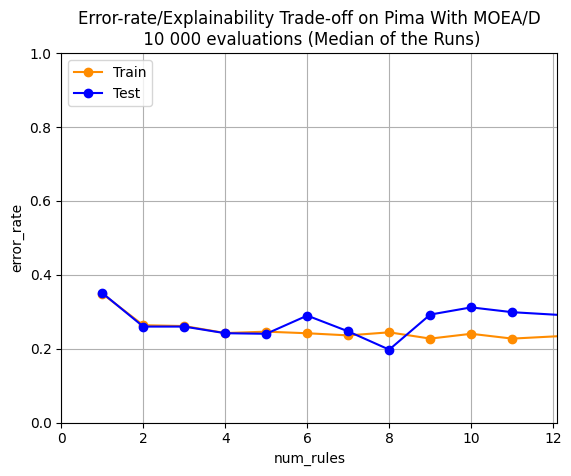

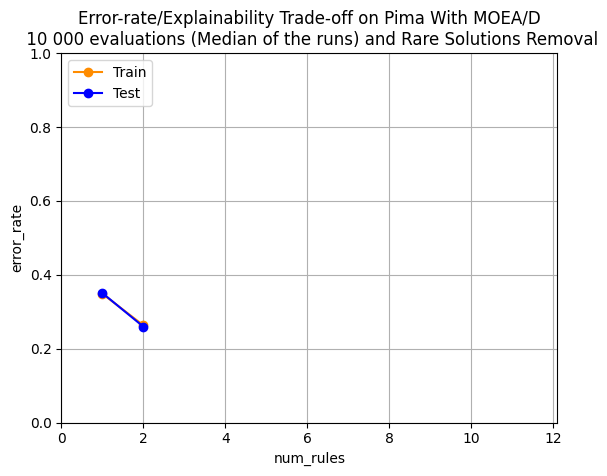

run times:
Q1:  41.20566928386688
Median :  44.000317096710205
Q3:  46.96130919456482
Average :  42.8703942378362
Std:  5.413642280066403
=========== DATASET bupa ===========



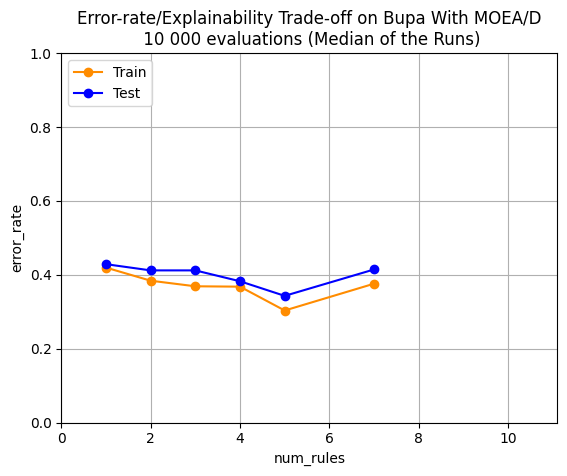

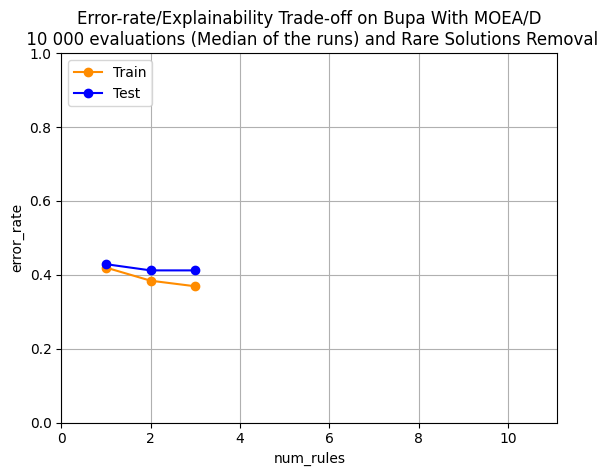

run times:
Q1:  23.145089626312256
Median :  24.45728826522827
Q3:  25.408520579338074
Average :  23.50129080613454
Std:  2.6757206992100273
=========== DATASET phoneme ===========



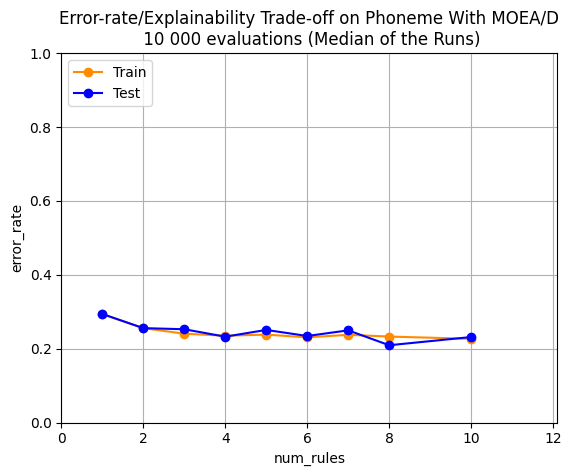

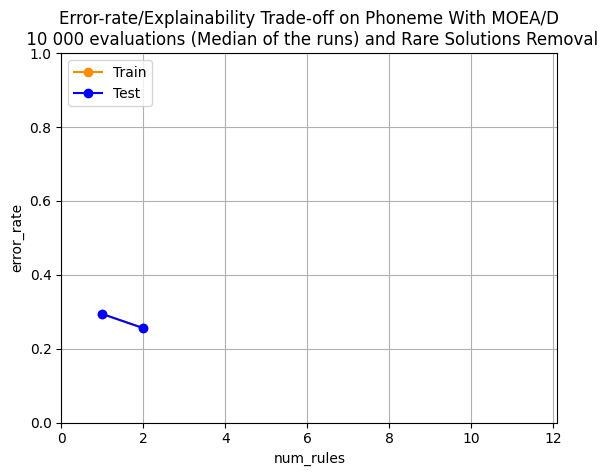

run times:
Q1:  228.14644408226013
Median :  238.65675628185272
Q3:  253.61652916669846
Average :  229.6225565433502
Std:  33.4406177053659


In [6]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "iris": (0,10.1),
    "pima": (0,12.1),
    "bupa": (0,11.1),
    "phoneme": (0, 12.1)
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in datasets:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"MOEAD{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"

    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]

    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With MOEA/D\n 10 000 evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/moead_{data_name}_10000eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)

    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()

    print("run times:")
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))

## Tests on NSGA-II with the hyperparameters of the study by Ono Renji (P-G-H only)

In [1]:
from mofgbmlpy.utility.parallel_cross_validation import run_cross_validation
from datetime import datetime
import gc


current_time = datetime.now()
time_str = current_time.strftime("%Y_%m_%d_%H_%M_%S")
# time_str = "2025_06_26_19_17_42"

# datasets = ["appendicitis", "bal", "bupa", "contraceptive", "ecoli", "haberman", "heart", "mammographic", "newthyroid", "page-blocks", "phoneme", "pima", "sonar", "spectfheart", "tae", "vehicle", "vowel", "wine", "wisconsin", "yeast" ]
datasets = ["bupa", "contraceptive", "pima"]
num_evals = 60000

In [2]:
for data_name in datasets:
    root_folder = "../.."
    results_root_folder = root_folder + "/results"
    algorithm_id = f"Ono_Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    args = [
        "--data-name", data_name,
        "--rand-seed", "2020",
        "--terminate-evaluation", f"{num_evals}",
        "--population-size", "60",
        # "--offspring-population-size", "60", # already the case by default
        "--objectives", "num-rules", "error-rate",
        "--algorithm-id", algorithm_id,
        "--root-folder", results_root_folder,
        "--algorithm", "nsga2",
    ]
    
    run_cross_validation(args, dataset_root, max_workers=2)
    gc.collect()

Running cross-validation experiments: 100%|██████████| 30/30 [35:13<00:00, 70.46s/ experiment]


Execution time: 2114.42


Running cross-validation experiments: 100%|██████████| 30/30 [4:18:27<00:00, 516.93s/ experiment]  


Execution time: 15508.65


Running cross-validation experiments: 100%|██████████| 30/30 [1:22:15<00:00, 164.53s/ experiment]


Execution time: 4936.80


=========== DATASET bupa ===========



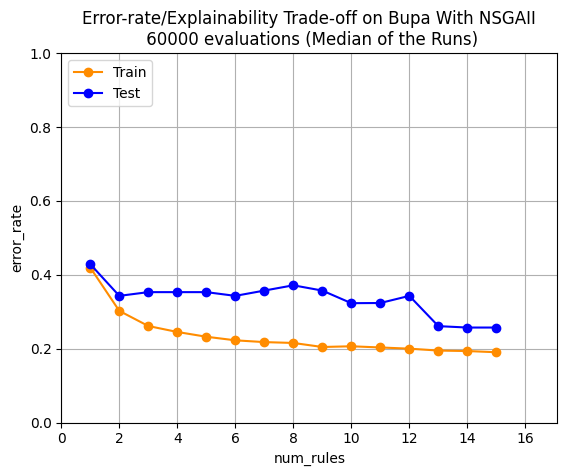

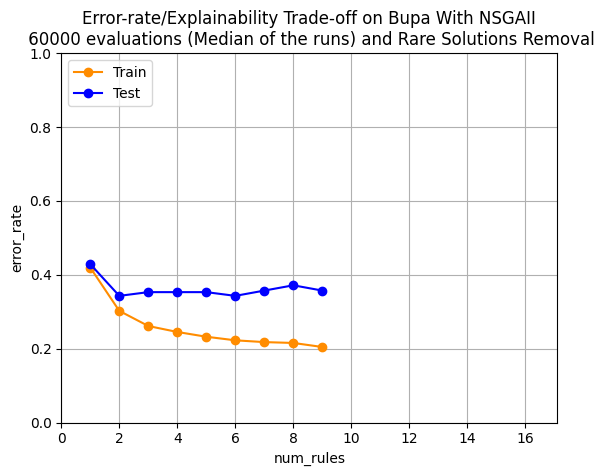

run times:
Q1:  85.39988178014755
Median :  93.85663092136383
Q3:  99.87700426578522
Average :  93.34754099051158
Std:  11.534174246562175
=========== DATASET contraceptive ===========



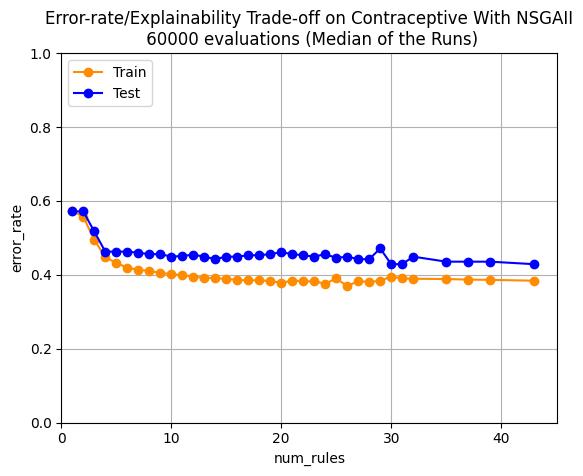

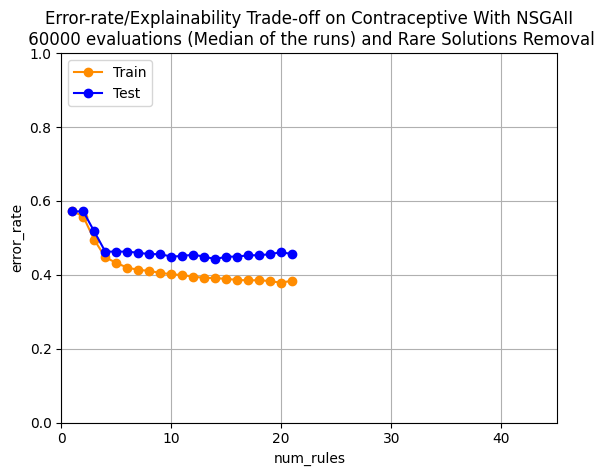

run times:
Q1:  698.455055296421
Median :  731.7953518629074
Q3:  794.5387942790985
Average :  748.5336713075637
Std:  88.43285749638665
=========== DATASET pima ===========



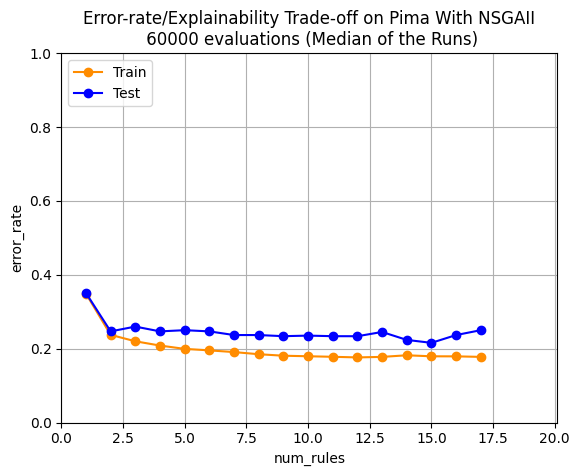

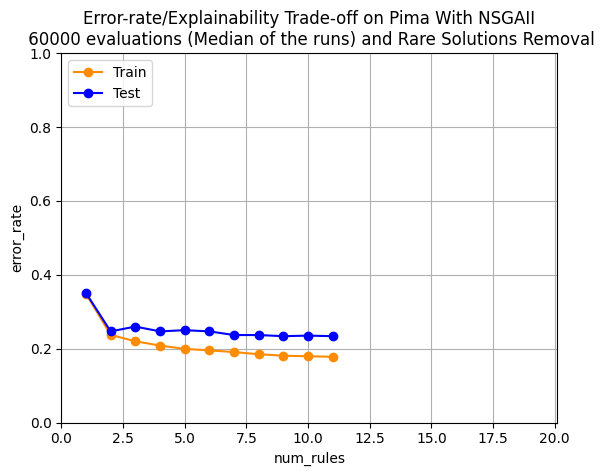

run times:
Q1:  211.3608285188675
Median :  231.3684709072113
Q3:  245.20676290988922
Average :  230.68527693748473
Std:  20.59594708697049


In [2]:
from mofgbmlpy.data.output import Output
from mofgbmlpy.utility.parallel_cross_validation import show_results_median_line_plot, get_results, show_results_box_plot
import numpy as np
from matplotlib import pyplot as plt

xlims = {
    "bupa":(0,17.1),
    "contraceptive":(0,45.1),
    "pima":(0,20.1)
}

root_folder = "../.."
results_root_folder = root_folder + "/results"
plot_dir = results_root_folder + "/plots"
Output.mkdirs(plot_dir)

for data_name in datasets:
    print(f"=========== DATASET {data_name} ===========\n")
    algorithm_id = f"Ono_Basic{data_name}Basic_{time_str}"
    dataset_root = root_folder + "/dataset"
    
    results = get_results(results_root_folder, algorithm_id, data_name)
    results_solutions = [run["solutions"] for run in results]
    run_times = [run["exec_time"] for run in results]
    
    # show_results_box_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=None)
    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n {num_evals} evaluations (Median of the Runs)"
    file_path = f"{plot_dir}/nsgaii_{data_name}_{num_evals}eval_median_line"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=False, xlim=xlims[data_name], title=title, file_path=file_path)

    title = f"Error-rate/Explainability Trade-off on {data_name.capitalize()} With NSGAII\n {num_evals} evaluations (Median of the runs) and Rare Solutions Removal"
    file_path = f"{plot_dir}/nsgaii_{data_name}_{num_evals}eval_median_line_rare_solutions_removal"
    show_results_median_line_plot(results_solutions, x_key="num_rules", remove_rare_solutions=True, xlim=xlims[data_name], title=title, file_path=file_path)
        
    # plt.boxplot(run_times)
    # plt.title("Execution time")
    # plt.show()
    print("run times:")
    print("Q1: ", np.quantile(run_times, 0.25))
    print("Median : ", np.median(run_times))
    print("Q3: ", np.quantile(run_times, 0.75))
    print("Average : ", np.mean(run_times))
    print("Std: ", np.std(run_times))
